In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

In [2]:
df=pd.read_csv('/kaggle/input/job-list-dataset/naukri_com-job_sample.csv')
df.shape

(22000, 14)

In [3]:
[col for col in df.columns if df[col].isnull().sum()>0]

['company',
 'education',
 'experience',
 'industry',
 'jobdescription',
 'joblocation_address',
 'numberofpositions',
 'payrate',
 'postdate',
 'site_name',
 'skills']

In [12]:
x_train,x_test,y_train,y_test=train_test_split(
df.drop(labels=['numberofpositions'],axis=1),
df['numberofpositions'],
test_size = 0.3,
random_state = 0
)

In [5]:
constant_features=[features for features in x_train.columns if x_train[features].std()==0]
len(constant_features)

TypeError: could not convert string to float: 'Airborne Recruiting Pvt. Ltd.'

In [6]:
# 1. Imports and setup
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

In [7]:
# 2. Load your dataset
df = pd.read_csv('/kaggle/input/job-list-dataset/naukri_com-job_sample.csv')
df.shape


(22000, 14)

In [8]:
# 3. Columns with missing values
[col for col in df.columns if df[col].isnull().sum() > 0]


['company',
 'education',
 'experience',
 'industry',
 'jobdescription',
 'joblocation_address',
 'numberofpositions',
 'payrate',
 'postdate',
 'site_name',
 'skills']

In [9]:
# 4. Split data (example: predicting 'numberofpositions'; change as needed)
x_train, x_test, y_train, y_test = train_test_split(
    df.drop(labels=['numberofpositions'], axis=1),
    df['numberofpositions'],
    test_size=0.3,
    random_state=0
)


In [10]:
# 5. Find constant features in training set (only works on numeric columns)
numeric_cols = x_train.select_dtypes(include=np.number).columns
constant_features = [features for features in numeric_cols if x_train[features].std() == 0]
len(constant_features), constant_features


(0, [])

In [15]:
# 6. Quasi-constant features (value counts > 0.99 in the train set)
quasi_constant_features = []
for col in numeric_cols:
    dominant_value = (x_train[col].value_counts() / float(len(x_train))).sort_values(ascending=False).values[0]
    if dominant_value > 0.99:
        quasi_constant_features.append(col)
len(quasi_constant_features), quasi_constant_features


(0, [])

In [14]:
# 7. Duplicate features (exact same values across all rows; only valid if columns are all numeric with no missing)
duplicated_features = []
for i in range(len(numeric_cols)):
    col_1 = numeric_cols[i]
    for col_2 in numeric_cols[i + 1:]:
        if x_train[col_1].equals(x_train[col_2]):
            duplicated_features.append(col_2)
duplicated_features = list(set(duplicated_features))
len(duplicated_features), duplicated_features


(0, [])

In [19]:
corrmat = x_train.corr()
fig, ax = plt.subplots()
fig.set_size_inches(16,16)
sns.heatmap(corrmat)

ValueError: could not convert string to float: 'Airborne Recruiting Pvt. Ltd.'

<Axes: >

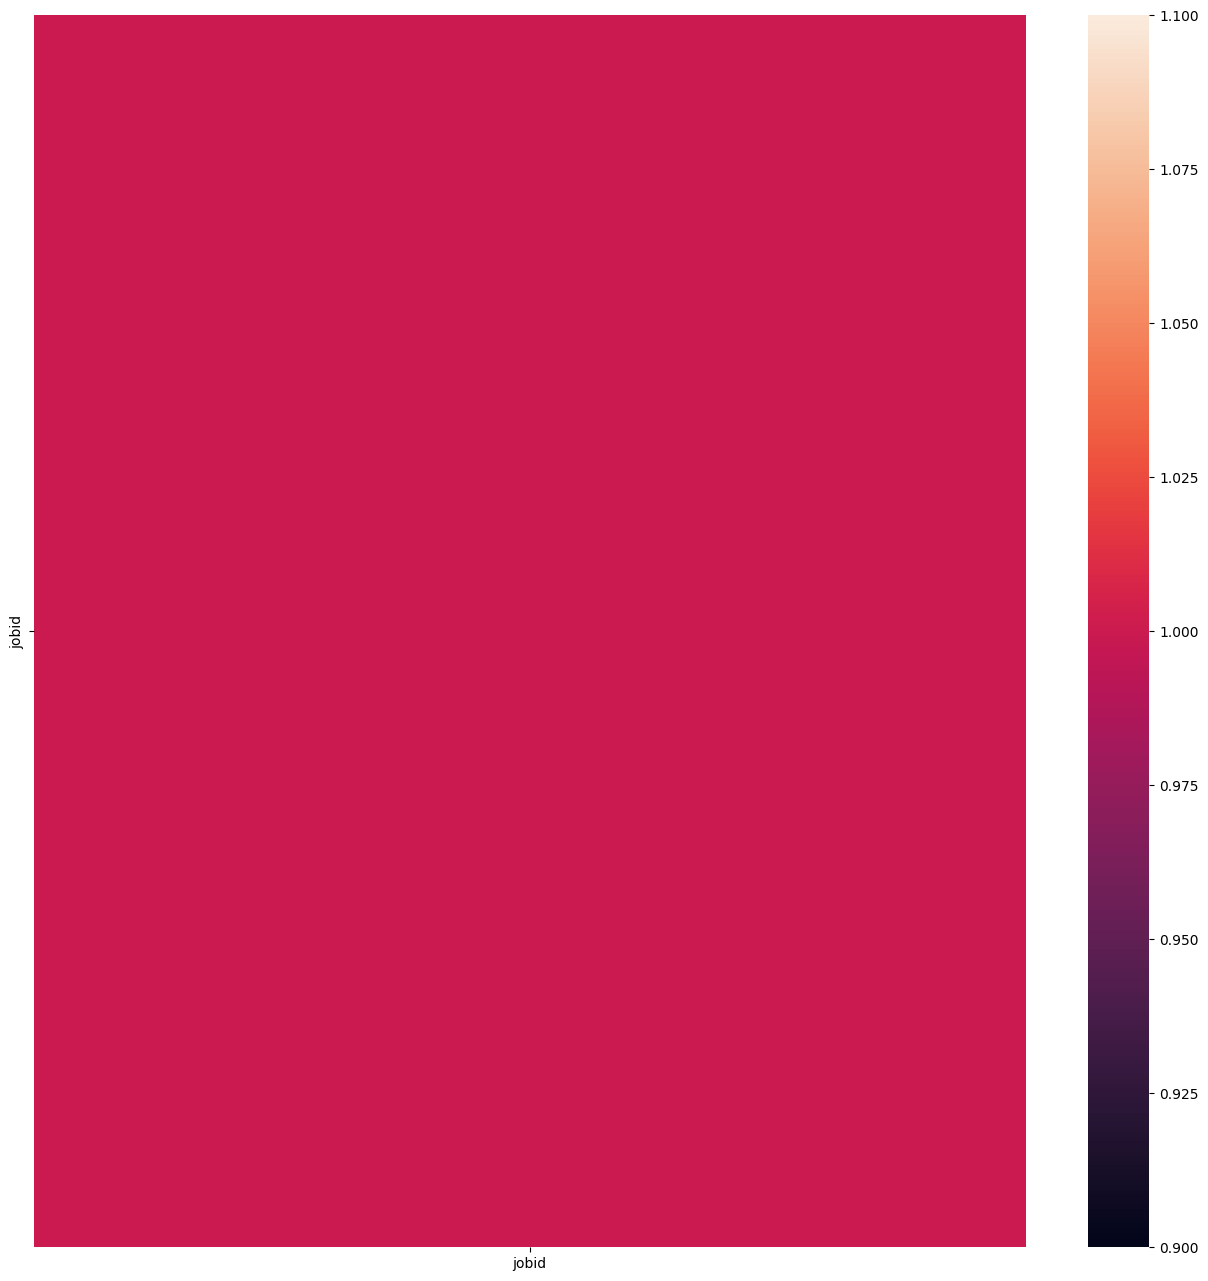

In [25]:
corrmat = x_train.select_dtypes(include=np.number).corr()
fig, ax = plt.subplots()
fig.set_size_inches(16,16)
sns.heatmap(corrmat)